# Reference Recovery Mean Spearman Demo

This notebook uses `MetaSort` on the first 100 Blood mixtures, recovers a bulk-adjusted reference matrix with `lambda_ref = 1.0`, and summarizes each mixture by the mean Spearman correlation across its cell types.

For each cell type, the correlation is:

`Spearman( recovered_profile[:, cell_type], original_profile[:, cell_type] )`

For each cumulative window (`1-20`, `1-40`, `1-60`, `1-80`, `1-100`), the boxplot shows the distribution of per-mixture mean Spearman values.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

CWD = Path.cwd().resolve()
candidates = [CWD, CWD.parent]
REPO_ROOT = next((path for path in candidates if (path / 'metasort').exists() and (path / 'data').exists()), None)
if REPO_ROOT is None:
    raise RuntimeError('Run this notebook from the MetaSort repository root or notebooks directory.')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from metasort.algorithm import load_bulk_signature_inputs
from metasort import MetaSortConfig, MetaSortSolver

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
DATA_ROOT = REPO_ROOT / 'data'
tissue_names = ['Blood']
n_mixtures = 100
cumulative_windows = [20, 40, 60, 80, 100]
lambda_ref = 0.6
RECOMPUTE = True

cfg = MetaSortConfig(
    lambda_hessian=1.0,
    lambda_avg_gradient=1.0,
    lambda_residual=1.5,
    lambda_gene_importance=0.0,
    lambda3=0.01,
    lambda4=0.001,
    convergence_tol=0.005,
    print_info=False,
)
solver = MetaSortSolver(cfg)


In [3]:
def recover_reference_profiles(reference: np.ndarray, bulk: np.ndarray, proportions: np.ndarray, lambda_ref: float) -> np.ndarray:
    reference = np.asarray(reference, dtype=float)
    bulk = np.asarray(bulk, dtype=float)
    proportions = np.asarray(proportions, dtype=float)
    denom = float(lambda_ref + np.sum(proportions ** 2))
    pred_bulk = reference @ proportions
    residual = bulk - pred_bulk
    recovered = reference + (residual[:, None] * proportions[None, :]) / max(denom, 1e-12)
    return np.clip(recovered, 0.0, None)


def run_one_mixture(tissue_name: str, mixture_name: str) -> tuple[pd.DataFrame, dict]:
    tissue_root = DATA_ROOT / tissue_name
    reference, bulk, _, cell_types = load_bulk_signature_inputs(tissue_root, mixture_name=mixture_name)
    result = solver.solve(reference, bulk, cell_types=cell_types)
    p_hat = np.asarray(result.proportions, dtype=float)
    recovered = recover_reference_profiles(reference, bulk, p_hat, lambda_ref=lambda_ref)

    celltype_rows = []
    for idx, cell_type in enumerate(cell_types):
        corr = spearmanr(reference[:, idx], recovered[:, idx]).correlation
        celltype_rows.append({
            'Tissue': tissue_name,
            'Mixture': mixture_name,
            'CellType': cell_type,
            'Spearman': float(corr),
        })

    detail_df = pd.DataFrame(celltype_rows)
    mixture_row = {
        'Tissue': tissue_name,
        'Mixture': mixture_name,
        'MeanSpearman': float(detail_df['Spearman'].mean()),
        'MinSpearman': float(detail_df['Spearman'].min()),
        'AllPass_0_8': bool((detail_df['Spearman'] >= 0.8).all()),
        'MetaSortIterations': int(result.iterations),
    }
    return detail_df, mixture_row


In [4]:
detail_out = REPO_ROOT / 'reference_recovery_mean_spearman_detail_blood_first100_lambda1.csv'
mixture_out = REPO_ROOT / 'reference_recovery_mean_spearman_summary_blood_first100_lambda1.csv'

if detail_out.exists() and mixture_out.exists() and not RECOMPUTE:
    detail_df = pd.read_csv(detail_out)
    mixture_df = pd.read_csv(mixture_out)
else:
    detail_frames = []
    mixture_rows = []

    for tissue in tissue_names:
        ratio_df = pd.read_csv(DATA_ROOT / tissue / 'bulkRatio.txt', sep='	', index_col=0)
        mixture_names = list(ratio_df.columns[:n_mixtures])
        for mixture_name in mixture_names:
            detail_piece, mixture_row = run_one_mixture(tissue, mixture_name)
            detail_frames.append(detail_piece)
            mixture_rows.append(mixture_row)

    detail_df = pd.concat(detail_frames, ignore_index=True)
    mixture_df = pd.DataFrame(mixture_rows)
    detail_df.to_csv(detail_out, index=False)
    mixture_df.to_csv(mixture_out, index=False)

mixture_df.head()


,Tissue,Mixture,MeanSpearman,MinSpearman,AllPass_0_8,MetaSortIterations
0,Blood,Mixture1,0.938852,0.715063,False,14
1,Blood,Mixture2,0.957031,0.801810,True,23
2,Blood,Mixture3,0.917036,0.701705,False,16
3,Blood,Mixture4,0.920980,0.737305,False,23
4,Blood,Mixture5,0.932098,0.728548,False,17


In [5]:
plot_df = mixture_df.copy()
plot_df['MixtureIndex'] = plot_df['Mixture'].str.extract(r'(\d+)').astype(int)
plot_df = plot_df.sort_values('MixtureIndex')

pd.DataFrame([
    {
        'MixtureRange': f'1-{n}',
        'N': int((plot_df['MixtureIndex'] <= n).sum()),
        'MeanOfMeanSpearman': float(plot_df.loc[plot_df['MixtureIndex'] <= n, 'MeanSpearman'].mean()),
        'MedianOfMeanSpearman': float(plot_df.loc[plot_df['MixtureIndex'] <= n, 'MeanSpearman'].median()),
        'StrictPassRate': float(plot_df.loc[plot_df['MixtureIndex'] <= n, 'AllPass_0_8'].mean()),
    }
    for n in cumulative_windows
])


,MixtureRange,N,MeanOfMeanSpearman,MedianOfMeanSpearman,StrictPassRate
0,1-20,20,0.927615,0.926191,0.150000
1,1-40,40,0.928897,0.927320,0.175000
2,1-60,60,0.929391,0.927763,0.166667
3,1-80,80,0.928534,0.926668,0.137500
4,1-100,100,0.927931,0.925681,0.130000


/tmp/ipykernel_936166/2507664903.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


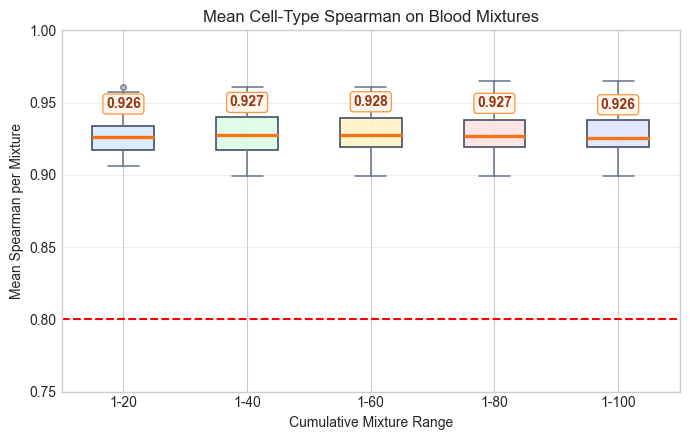

In [ ]:
plot_df = mixture_df.copy()
plot_df['MixtureIndex'] = plot_df['Mixture'].str.extract(r'(\d+)').astype(int)
plot_df = plot_df.sort_values('MixtureIndex')

groups = [plot_df.loc[plot_df['MixtureIndex'] <= n, 'MeanSpearman'].to_numpy() for n in cumulative_windows]
labels = [f'1-{n}' for n in cumulative_windows]
median_values = [float(np.median(values)) for values in groups]

fig, ax = plt.subplots(figsize=(7, 4.5))
box = ax.boxplot(
    groups,
    labels=labels,
    patch_artist=True,
    medianprops={'color': '#f97316', 'linewidth': 2.4},
    boxprops={'linewidth': 1.2, 'color': '#334155'},
    whiskerprops={'linewidth': 1.1, 'color': '#64748b'},
    capprops={'linewidth': 1.1, 'color': '#64748b'},
    flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': '#94a3b8', 'markeredgecolor': '#475569', 'alpha': 0.65},
)

box_colors = ['#dbeafe', '#dcfce7', '#fef3c7', '#fee2e2', '#e0e7ff']
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.92)

for x, median_value in enumerate(median_values, start=1):
    ax.text(
        x,
        median_value + 0.018,
        f'{median_value:.3f}',
        ha='center',
        va='bottom',
        color='#9a3412',
        fontsize=10,
        fontweight='bold',
        bbox={'boxstyle': 'round,pad=0.22', 'facecolor': '#fff7ed', 'edgecolor': '#fb923c', 'linewidth': 0.9},
    )

ax.axhline(0.8, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Mean Cell-Type Spearman on Blood Mixtures')
ax.set_xlabel('Cumulative Mixture Range')
ax.set_ylabel('Mean Spearman per Mixture')
ax.set_ylim(0.75, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
detail_out, mixture_out


(PosixPath('/home/yunhao/WeightOptimizationDebug/metasort_jk/reference_recovery_mean_spearman_detail_blood_first100_lambda1.csv'),
 PosixPath('/home/yunhao/WeightOptimizationDebug/metasort_jk/reference_recovery_mean_spearman_summary_blood_first100_lambda1.csv'))